In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
path = "dataset2"
IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

In [3]:
train = keras.utils.image_dataset_from_directory(
    path,
    batch_size = BATCH_SIZE,
    image_size = IMG_SIZE,
    seed = SEED,
    validation_split = 0.2,
    subset = "training"
)

Found 2245 files belonging to 3 classes.
Using 1796 files for training.


In [4]:
val = keras.utils.image_dataset_from_directory(
    path,
    batch_size = BATCH_SIZE,
    image_size = IMG_SIZE,
    seed = SEED,
    validation_split = 0.2,
    subset = "validation"
)

Found 2245 files belonging to 3 classes.
Using 449 files for validation.


In [5]:
class_names = train.class_names
class_names

['paper', 'rock', 'scissors']

In [6]:
for image_batch, labels_batch in train:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(32, 224, 224, 3)
(32,)


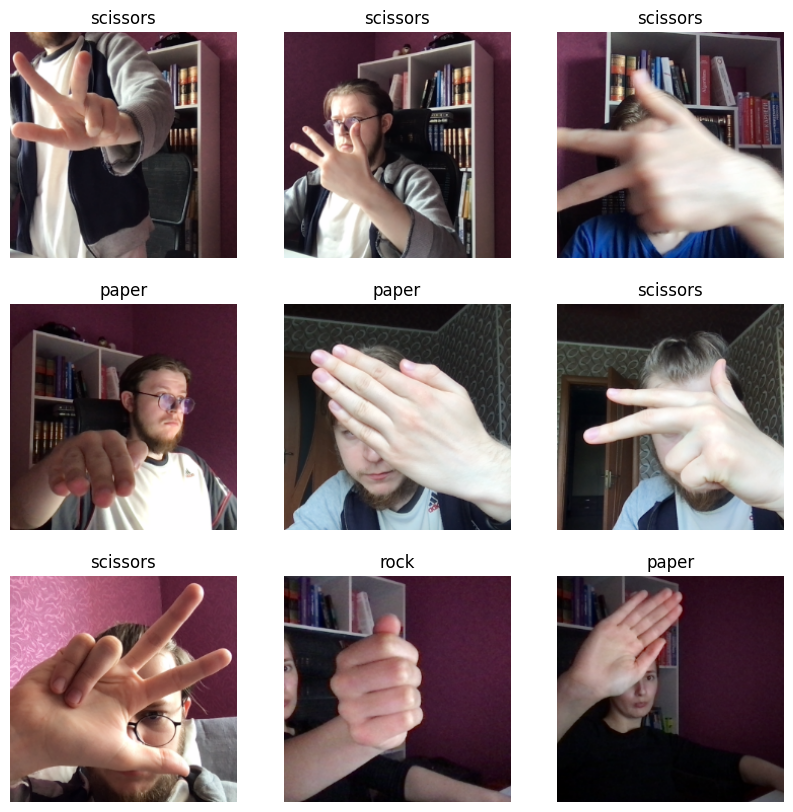

In [7]:
plt.figure(figsize=(10, 10))
for images, labels in train.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [8]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=42),
  tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
  tf.keras.layers.RandomBrightness(factor = 0.2)
])

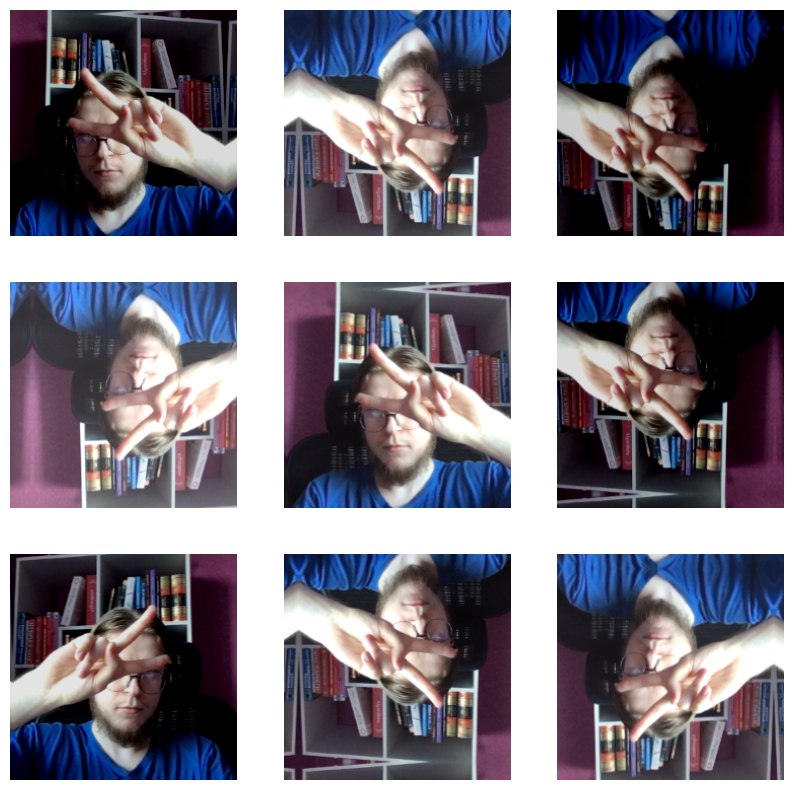

In [9]:
plt.figure(figsize=(10, 10))
for images, _ in train.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (224,224,3)),
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
   
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation = 'softmax')
])

In [11]:
model.compile(
    optimizer = 'adam',
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

model.summary()

early_stop = keras.callbacks.EarlyStopping(monitor = "val_loss", mode = "auto", patience = 3, verbose = 1, restore_best_weights=False)


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 224, 224, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 56, 56, 64)        0         
 g2D)                                                

In [12]:
history = model.fit(train, epochs=50, validation_data = val, callbacks=[early_stop])

Epoch 1/50


57/57 [==============================] - 31s 522ms/step - loss: 1.2722 - accuracy: 0.3291 - val_loss: 1.0856 - val_accuracy: 0.3987
Epoch 2/50
57/57 [==============================] - 30s 520ms/step - loss: 1.0758 - accuracy: 0.3792 - val_loss: 1.0558 - val_accuracy: 0.4053
Epoch 3/50
57/57 [==============================] - 38s 665ms/step - loss: 1.0587 - accuracy: 0.4076 - val_loss: 1.0443 - val_accuracy: 0.4477
Epoch 4/50
57/57 [==============================] - 32s 556ms/step - loss: 1.0628 - accuracy: 0.4003 - val_loss: 1.0605 - val_accuracy: 0.4254
Epoch 5/50
57/57 [==============================] - 27s 474ms/step - loss: 1.0617 - accuracy: 0.3909 - val_loss: 1.0508 - val_accuracy: 0.4143
Epoch 6/50
57/57 [==============================] - 28s 483ms/step - loss: 1.0548 - accuracy: 0.4003 - val_loss: 1.0331 - val_accuracy: 0.4454
Epoch 7/50
57/57 [==============================] - 29s 501ms/step - loss: 1.0381 - accuracy: 0.4310 - val_loss: 1.2930 - val_accuracy: 0.39

In [13]:
from pathlib import Path
save_dir = Path('models')
save_dir.mkdir(exist_ok=True) 

model_path = save_dir / 'testkeobuabao3.keras'
model.save(model_path)

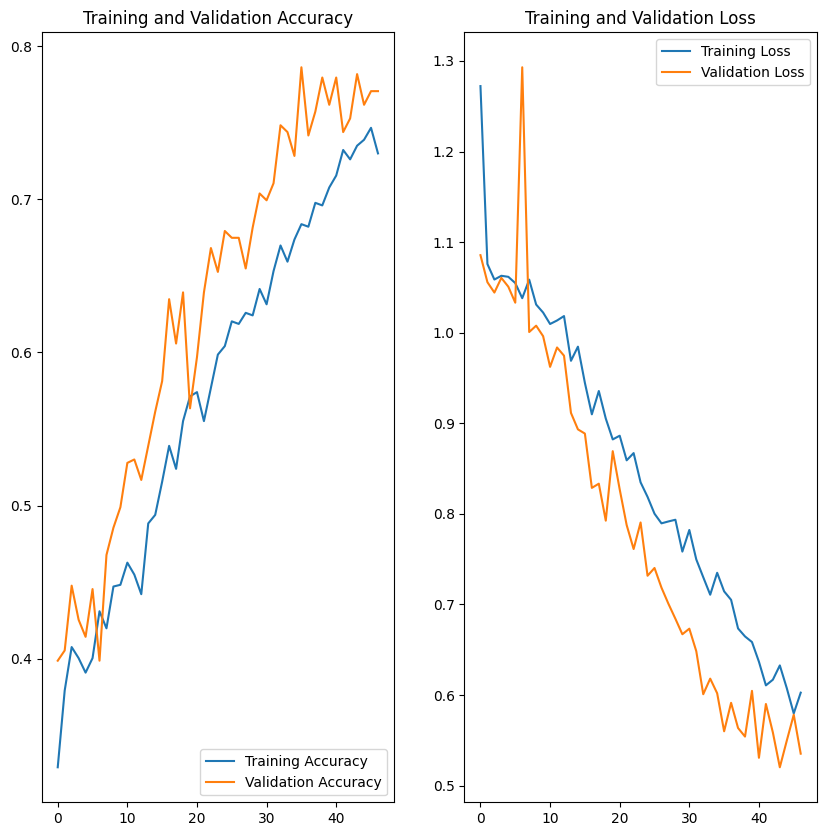

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
import numpy as np
import cv2 
from tensorflow import keras

model = keras.models.load_model("Models/testkeobuabao3.keras")
class_name = ["Bao", "Bua", "Keo"]

img_path = "Data\\Raw\\test.jpg"
img = cv2.imread(img_path)

img_resize = cv2.resize(img, IMG_SIZE)
img_color = cv2.cvtColor(img_resize, cv2.COLOR_BGR2RGB)

img_input = np.expand_dims(img_color, axis = 0)

predict = model.predict(img_input, verbose = 0)
label = class_name[np.argmax(predict)]
score = np.max(predict)

print(f"ket qua: {label}, ti le: {score}")

ket qua: Keo, ti le: 0.8458306789398193
